# Simple Tidy3D Waveguide Simulation

This notebook simulates a silicon waveguide with a point source and field monitor to visualize electromagnetic wave propagation at telecom wavelengths (1.55 μm).

## Setup

In [2]:
import numpy as np
import tidy3d as td

import tidy3d.web as web
web.configure("x6XSlijKJkm6DKZpr9T8lkj6gLMTFkhyTELOwH48B8BrXoya")

Configuration saved successfully.


## Define Simulation Parameters

In [3]:
# Central wavelength and frequency
wavelength = 1.55  # micrometers (telecom wavelength)
frequency = td.C_0 / wavelength  # frequency in Hz

# Silicon waveguide dimensions
wg_width = 0.5  # micrometers
wg_height = 0.22  # micrometers
wg_length = 5.0  # micrometers

print(f"Wavelength: {wavelength} µm")
print(f"Frequency: {frequency:.3e} Hz")
print(f"Waveguide dimensions: {wg_width} × {wg_height} µm")

Wavelength: 1.55 µm
Frequency: 1.934e+14 Hz
Waveguide dimensions: 0.5 × 0.22 µm


## Create Materials

In [4]:
# Silicon with refractive index ~3.5 at 1.55 µm
silicon = td.Medium(permittivity=3.5**2)

# Vacuum (air)
vacuum = td.Medium(permittivity=1.0)

## Define Structures

In [5]:
# Silicon waveguide centered at y=0
waveguide = td.Structure(
    geometry=td.Box(
        center=(0, 0, 0),
        size=(td.inf, wg_width, wg_height)
    ),
    medium=silicon,
    name="silicon_waveguide"
)

## Define Source and Monitors

In [6]:
# Point source at the entrance
source = td.PointDipole(
    center=(-wg_length/2 + 0.5, 0, 0),
    source_time=td.GaussianPulse(freq0=frequency, fwidth=frequency/10),
    polarization="Hz",
    name="source"
)

# Field monitor to record the fields
field_monitor = td.FieldMonitor(
    center=(0, 0, 0),
    size=(wg_length, wg_width + 1.0, wg_height + 1.0),
    freqs=[frequency],
    name="field"
)

## Define Simulation Domain

In [8]:
# Create simulation
sim = td.Simulation(
    center=(0, 0, 0),
    size=(wg_length + 2.0, wg_width + 3.0, wg_height + 3.0),
    structures=[waveguide],
    sources=[source],
    monitors=[field_monitor],
    run_time=25 / frequency,  # Run for 25 periods
    
    # Correct way to apply PML everywhere
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    
    medium=vacuum
)

print(sim)

Simulation(
    center=(0.0, 0.0, 0.0),
    size=(7.0, 3.5, 3.22),
    medium=Medium(
        name=None,
        frequency_range=None,
        allow_gain=False,
        nonlinear_spec=None,
        modulation_spec=None,
        viz_spec=None,
        heat_spec=None,
        permittivity=1.0,
        conductivity=0.0
    ),
    structures=(
        Structure(
            geometry=Box(center=(0.0, 0.0, 0.0), size=(inf, 0.5, 0.22)),
            name='silicon_waveguide',
            background_permittivity=None,
            background_medium=None,
            priority=None,
            medium=Medium(
                name=None,
                frequency_range=None,
                allow_gain=False,
                nonlinear_spec=None,
                modulation_spec=None,
                viz_spec=None,
                heat_spec=None,
                permittivity=12.25,
                conductivity=0.0
            )
        ),
    ),
    symmetry=(0, 0, 0),
    sources=(
        PointDipole(

## Visualize Setup

In [9]:
# Plot the simulation in 3D
fig = sim.plot_3d()

## Estimate Cost

In [11]:
job = web.Job(simulation=sim, task_name="waveguide_simulation")

# 2. Estimate the cost using the task ID managed by the job
estimated_cost = web.estimate_cost(job.task_id)
print(f"Estimated cost: {estimated_cost} Flex credits")

00:59:38 Eastern Daylight Time Created task 'waveguide_simulation' with         
                               resource_id                                      
                               'fdve-e744326e-da6a-4f8c-995f-0d0a585b7f5b' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=734016;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e744326e-da6a-4f8c-995f-0d0a585b7f5b\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=827622;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e744326e-da6a-4f8c-995f-0d0a585b7f5b\taskId]8;;\
                               ]8;id=734016;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e744326e-da6a-4f8c-995f-0d0a585b7f5b\=]8;;\]8;id=805696;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e744326e-da6a-4f8c-995f-0d0a585b7f5b\fdve]8;;\]8;id=734016;https://tidy3d.simulation.cloud/workbench?taskId=fdve-e744326e-da6a-4f8c-995f-0d0a585b7f5b\-e744326e-da6a-4f8c-995f-0d0a585b7f5b']8;;\.

                               Task folder: ]8;id=22496;https://tidy3d.simulation.cloud/folders/folder-b30c40e7-2a8c-4e41-8553-e5d0efc407c0\'default']8;;\.

Output()

00:59:42 Eastern Daylight Time Estimated FlexCredit cost: 0.025. Minimum cost   
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

Estimated cost: 0.025 Flex credits


## Run the Simulation

In [18]:
# Run the simulation, block until finished, and save the HDF5 data locally
sim_data = web.run(
    sim, 
    task_name="simple_waveguide", 
    path="data/simple_waveguide_data.hdf5", 
    verbose=True
)

print("Simulation completed and data downloaded!")

01:13:01 Eastern Daylight Time Created task 'simple_waveguide' with resource_id 
                               'fdve-2c699f15-c110-4c08-86e6-995583d11de5' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=369889;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2c699f15-c110-4c08-86e6-995583d11de5\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=319216;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2c699f15-c110-4c08-86e6-995583d11de5\taskId]8;;\
                               ]8;id=369889;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2c699f15-c110-4c08-86e6-995583d11de5\=]8;;\]8;id=968610;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2c699f15-c110-4c08-86e6-995583d11de5\fdve]8;;\]8;id=369889;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2c699f15-c110-4c08-86e6-995583d11de5\-2c699f15-c110-4c08-86e6-995583d11de5']8;;\.

                               Task folder: ]8;id=418923;https://tidy3d.simulation.cloud/folders/folder-b30c40e7-2a8c-4e41-8553-e5d0efc407c0\'default']8;;\.

Output()

01:13:03 Eastern Daylight Time Estimated FlexCredit cost: 0.025. Minimum cost   
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

01:13:05 Eastern Daylight Time status = success

Output()

01:13:07 Eastern Daylight Time Loading results from                             
                               data\simple_waveguide_data.hdf5

                               WARNING: Simulation final field decay value of   
                               0.519 is greater than the simulation shutoff     
                               threshold of 1e-05. Consider running the         
                               simulation again with a larger 'run_time'        
                               duration for more accurate results.              

Simulation completed and data downloaded!


## Analyze Results

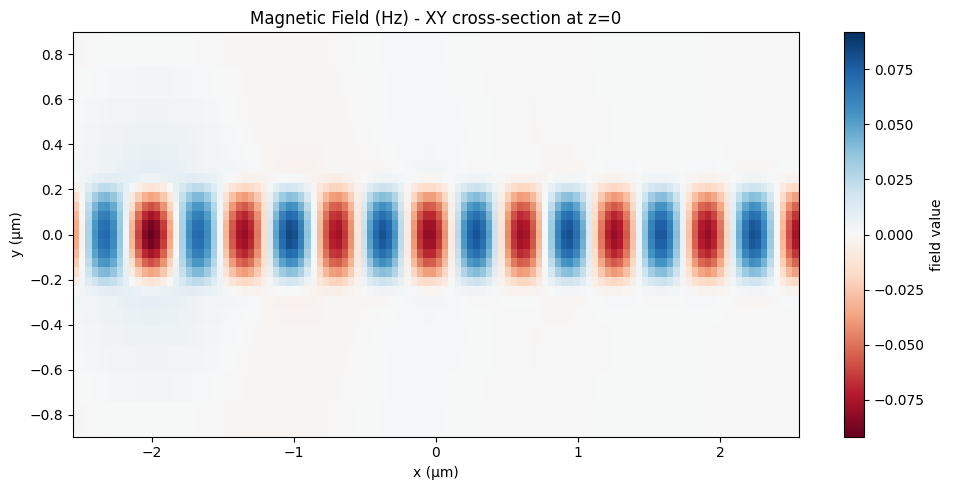

In [21]:
import matplotlib.pyplot as plt
# Extract the field data from the simulation results
field_data = sim_data["field"]

# Extract the cross-section at z=0 for the target frequency
# We look at Hz because your source was Hz polarized
field_at_z0 = field_data.Hz.sel(z=0, f=frequency, method="nearest")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
field_at_z0.real.plot(x="x", y="y", ax=ax, cmap="RdBu")

ax.set_title("Magnetic Field (Hz) - XY cross-section at z=0")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
plt.tight_layout()
plt.show()